In [1]:
import torch
import torch.nn as nn

In relative positional embedding for a token pair there is an embedding, w.r.t. to given context
(4, 6) => (4, 6, 64)
2 tokens that are 3 distance aprt , will be represented by same bias , irrespective of thier absolute position


In RoPE we don't crate additional positional embedding for a token, rather rotate the vector representing that token by some amount, depending upon the point in context it appears
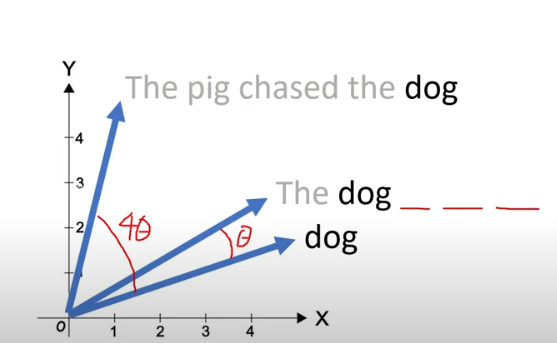


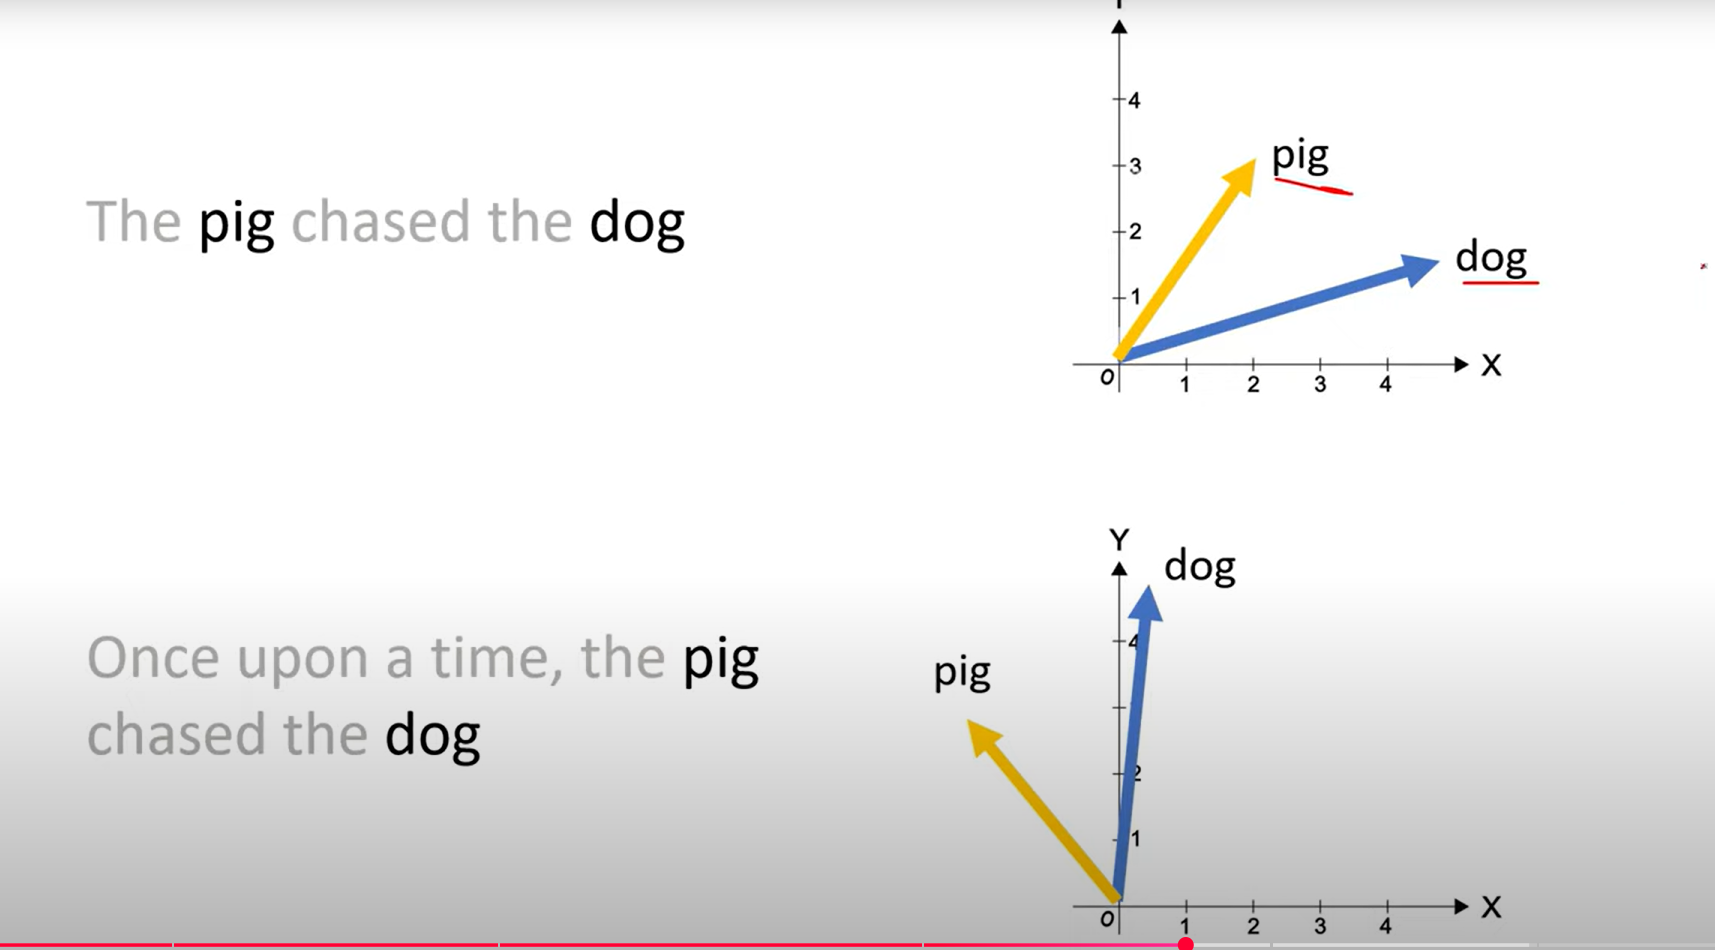


relative distance in RoPE reamin preserved
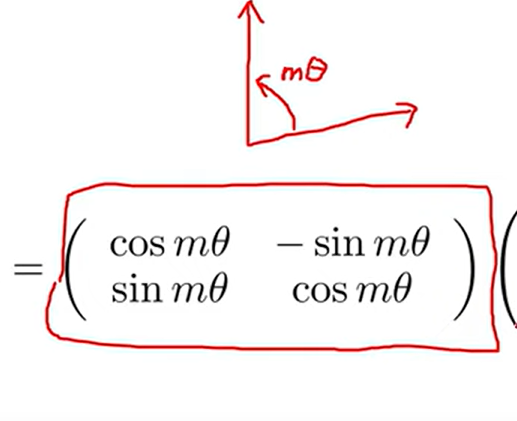


Above m is the absolute poisition of a token, and theta is the angle by which it need to be rotated


In [122]:
base = 10000
n_embd = 6
block_size = 8

In [123]:
theta = 1.0 / (base ** (torch.arange(0, n_embd, 2).float() / n_embd))

In [124]:
theta.shape
#inv freq

torch.Size([3])

In [125]:
t = torch.arange(block_size, dtype=torch.float32)
t.shape

torch.Size([8])

In [117]:
t1 = torch.einsum('i,j->ij', t, theta)

In [126]:
t2 = (t.unsqueeze(1) * theta.unsqueeze(0))

In [131]:
t2

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 4.6416e-02, 2.1544e-03],
        [2.0000e+00, 9.2832e-02, 4.3089e-03],
        [3.0000e+00, 1.3925e-01, 6.4633e-03],
        [4.0000e+00, 1.8566e-01, 8.6177e-03],
        [5.0000e+00, 2.3208e-01, 1.0772e-02],
        [6.0000e+00, 2.7850e-01, 1.2927e-02],
        [7.0000e+00, 3.2491e-01, 1.5081e-02]])

In [31]:
torch.all(t1 == t2)

tensor(True)

In [ ]:
t1.shape, t1.shape

torch.Size([8, 32])

In [49]:
cache = torch.stack([torch.cos(t1), torch.sin(t2)], dim=-1)

In [50]:
cache.shape

torch.Size([8, 32, 2])

In [51]:
rope_cahce = cache[:block_size]

In [53]:
rope_cahce.shape

torch.Size([8, 32, 2])

In [54]:
B = 7
T = block_size
n_head = 4
head_size = n_embd // n_head

In [70]:
x = torch.randn((B, T, n_embd))
x.shape

torch.Size([7, 8, 64])

In [71]:
x = x.reshape(*x.shape[:-1], -1, 2) #B, T, n_embd, pairs, 2
x.shape

torch.Size([7, 8, 32, 2])

In [94]:
sin = rope_cahce[..., 0]
cos = rope_cahce[..., 1]

In [95]:
sin.shape, cos.shape,cos[:T, :].unsqueeze(0).shape

(torch.Size([8, 32]), torch.Size([8, 32]), torch.Size([1, 8, 32]))

In [96]:
cos = cos[:T, :].unsqueeze(0)

In [97]:
cos.shape

torch.Size([1, 8, 32])

In [98]:
(x[..., 0] * cos).shape

torch.Size([7, 8, 32])

RuntimeError: The size of tensor a (7) must match the size of tensor b (8) at non-singleton dimension 1

In [104]:
import torch
import torch.nn as nn
from RotaryPositionalEmbedding import RotaryPositionalEmbedding

torch.manual_seed(1337)
torch.random.manual_seed(1337)

class RotaryPositionalEmbedding_gg(nn.Module):
    def __init__(self, dim, max_seq_len=2048, base=10000):
        super().__init__()
        self.dim = dim
        self.max_seq_len = max_seq_len
        self.base = base

        # Precompute frequencies for rotation
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

        # Precompute cached positional embeddings (cos and sin)
        t = torch.arange(max_seq_len, dtype=torch.float32)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1) # Concatenate to handle pairs of dimensions
        self.register_buffer('cos_cached', emb.cos()[None, None, :, :])
        self.register_buffer('sin_cached', emb.sin()[None, None, :, :])

    def forward(self, x, seq_len=None):
        # x shape: (batch_size, num_heads, seq_len, head_dim)
        if seq_len is None:
            seq_len = x.shape[-2]

        # Ensure cached embeddings are long enough
        if seq_len > self.max_seq_len:
            raise ValueError(f"Sequence length {seq_len} exceeds max_seq_len {self.max_seq_len}. "
                             "Consider increasing max_seq_len or recomputing frequencies.")

        cos_pos = self.cos_cached[:, :, :seq_len, :]
        sin_pos = self.sin_cached[:, :, :seq_len, :]

        # Apply RoPE
        x_rot = self._rotate_half(x)
        return x * cos_pos + x_rot * sin_pos

    def _rotate_half(self, x):
        # Divides the input into two halves and swaps them, negating one half
        x1, x2 = x.chunk(2, dim=-1)
        return torch.cat((-x2, x1), dim=-1)

# Example Usage:
if __name__ == "__main__":
    batch_size = 2
    num_heads = 8
    seq_len = 10
    head_dim = 64 # Must be even for RoPE

    # Create dummy query/key tensor
    query_key_tensor = torch.randn(batch_size, num_heads, seq_len, head_dim)

    # Initialize RoPE
    rope = RotaryPositionalEmbedding_gg(dim=head_dim, max_seq_len=seq_len)
    rope_1 = rope = RotaryPositionalEmbedding(n_embd=head_dim, max_seq=seq_len)

    # Apply RoPE
    rotated_tensor = rope(query_key_tensor)
    rotated_tensor_1 = rope_1(query_key_tensor)

    print(torch.all(rotated_tensor == rotated_tensor_1))

    print("Original tensor shape:", query_key_tensor.shape)
    print("Rotated tensor shape:", rotated_tensor.shape)
    print("Example of rotated values (first element):", rotated_tensor[0, 0, 0, :4])
    print("Example of rotated values (first element):", rotated_tensor_1[0, 0, 0, :4])

tensor(True)
Original tensor shape: torch.Size([2, 8, 10, 64])
Rotated tensor shape: torch.Size([2, 8, 10, 32, 2])
Example of rotated values (first element): tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643]])
Example of rotated values (first element): tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643]])
